<a href="https://colab.research.google.com/github/suzanafaria/predictive_maintenance_ml/blob/main/predictive_maintenance_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Maintenance using Machine Learning

## Project Overview
Unexpected failures in industrial equipment can lead to production downtime, safety risks, and significant financial losses. This project aims to build machine learning models capable of predicting machine failures using sensor data.

## Business Goal
Identify high-risk equipment before failure occurs to support predictive maintenance strategies.

## Dataset
AI4I 2020 Predictive Maintenance Dataset (10,000 observations)

## Models Evaluated
- Logistic Regression (baseline)
- Random Forest

## 1. Dataset overview
Before modeling, it is essential to understand the dataset structure, variable types, and data quality.

The dataset contains operational and sensor measurements from industrial machines, along with a binary target indicating failure.

Inspect dataset structure:
  - number of rows and columns;
  - variable types;
  - missing values

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## 2. Exploratory Data Analysis (EDA)

The goal is to identify patterns and relationships between machine behavior and failures.

Main questions:
- Is the dataset balanced?
- Which variables differ between failed and non-failed machines?
- Which features may be useful for prediction?


In [7]:
df["Machine failure"].value_counts()

,count
Machine failure,
0,9661
1,339


###Insights:

After analyse the target variable distribution, it was notice the dataset is highly imbalanced:
- 96.61% of machines did not fail
- 3.39% of machines failed

This indicates a classification imbalance problem, meaning accuracy alone is not a reliable metric for model evaluation. Other metrics  such as recall and F1-score will be especially important.

In [8]:
df.groupby("Machine failure")[[
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]].mean().round(2)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.97,310.00,1540.26,39.63,106.69
1,300.89,310.29,1496.49,50.17,143.78


### Boxplot Visualization
 Comparison sensor variables (Torque and Tool Wear) between machines with failure and no failure to identify potential predictive features.


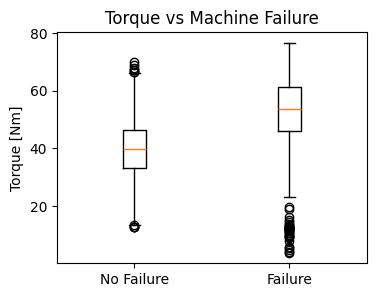

In [9]:
plt.figure(figsize=(4,3))
plt.boxplot([
    df[df["Machine failure"] == 0]["Torque [Nm]"],
    df[df["Machine failure"] == 1]["Torque [Nm]"]
])

plt.xticks([1, 2], ["No Failure", "Failure"])
plt.ylabel("Torque [Nm]")
plt.title("Torque vs Machine Failure")
plt.show()

### Insights after analyse the boxplots:

Machines that failed tend to operate under higher torque levels (~ 50-60 Nm). This suggests mechanical stress may be a major failure driver.


In [10]:
corr = df[[
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Machine failure"
]].corr().round(2)

display(corr)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.00,0.88,0.02,-0.01,0.01,0.08
Process temperature [K],0.88,1.00,0.02,-0.01,0.01,0.04
Rotational speed [rpm],0.02,0.02,1.00,-0.88,0.00,-0.04
Torque [Nm],-0.01,-0.01,-0.88,1.00,-0.00,0.19
Tool wear [min],0.01,0.01,0.00,-0.00,1.00,0.11
Machine failure,0.08,0.04,-0.04,0.19,0.11,1.00


## 3. Data Cleaning and Preprocessing

Steps:
1. Remove irrelevant columns: `UDI` and `Product ID`
2. Remove leakage-prone features: `TWF`, `HDF`, `PWF`, `OSF`, `RNF` (they directly indicate failure causes)
3. Encode categorical variables: `Machine Failure` (need to convert categoric variable string type into number)
4. Split train/test sets


In [11]:
df = df.drop(columns=["UDI", "Product ID"]);
df = df.drop(columns=["TWF", "HDF", "PWF", "OSF", "RNF"])
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["Type"] = encoder.fit_transform(df["Type"])

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,2,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0
3,1,298.2,308.6,1433,39.5,7,0
4,1,298.2,308.7,1408,40.0,9,0


In [13]:
X = df.drop(columns=["Machine failure"])
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,2,298.1,308.6,1551,42.8,0
1,1,298.2,308.7,1408,46.3,3
2,1,298.1,308.5,1498,49.4,5
3,1,298.2,308.6,1433,39.5,7
4,1,298.2,308.7,1408,40.0,9


In [14]:
y = df["Machine failure"]
y.head()

,Machine failure
0,0
1,0
2,0
3,0
4,0


### Machine Failure Data Distribution:

---



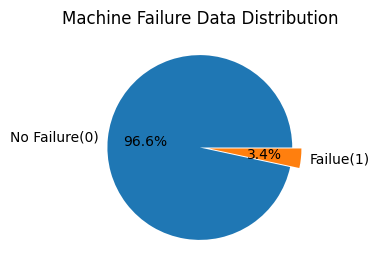

In [15]:
target=y.value_counts()
labels=['No Failure(0)','Failue(1)']

plt.figure(figsize=(3,3))
plt.pie(target,labels=labels,autopct='%1.1f%%',explode=[0, 0.1])
plt.title("Machine Failure Data Distribution")
plt.show()

### Split Test/Train dataset:

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(8000, 6) (2000, 6)
(8000,) (2000,)


## 6. Logistic Regression (baseline model)

Simple baseline model to establish a performance reference before testing more complex models (Random Forest).

- Model Creation
- Model evaluation with accuracy, precision, recall and F1-score metrics and confusion matrix

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [18]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
pred_lr[:50]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0])

In [19]:
accuracy = accuracy_score(y_test, pred_lr)
print(f"Accuracy score: {accuracy}")

Accuracy score: 0.9675


In [20]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.60      0.13      0.22        68

    accuracy                           0.97      2000
   macro avg       0.79      0.56      0.60      2000
weighted avg       0.96      0.97      0.96      2000



### Logistic Regression Insights:

Although the model achieved high accuracy (~97%), recall for the failure class was only 13%.

This means most failures were not detected, making this model unsuitable for predictive maintenance.

In [21]:
cm_lr = confusion_matrix(y_test, pred_lr)
print(f"Confusion matrix:\n{cm_lr}")

Confusion matrix:
[[1926    6]
 [  59    9]]


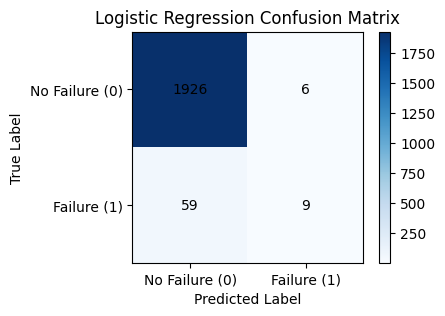

In [22]:
plt.figure(figsize=(4,3))
plt.imshow(cm_lr, cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["No Failure (0)", "Failure (1)"])
plt.yticks([0, 1], ["No Failure (0)", "Failure (1)"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        plt.text(
            j, i,
            cm_lr[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.show()

### Insights from Logistic Regression Confusion Matrix:
- The model correctly classified most non-failure cases, which explains its high accuracy.
- The baseline model *failed* to detect the majority of failure events, generating a high number of *false negatives* (~59). This is problematic in predictive maintenance, since missed failures may result in unexpected downtime and operational losses.


## 7. Random Forest

Random Forest was selected because tree-based models typically perform well on tabular industrial data and capture non-linear feature interactions.

- Model Creation
- Model evaluation with accuracy, precision, recall and F1-score metrics and confusion matrix

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [24]:
rfc = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42
)

rfc.fit(X_train, y_train)
pred_rfc = rfc.predict(X_test)

print(pred_rfc)

[0 0 0 ... 0 0 0]


In [25]:
accuracy = accuracy_score(y_test, pred_rfc)
print(f"Accuracy score: {accuracy}")

Accuracy score: 0.984


In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_rfc))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.86      0.63      0.73        68

    accuracy                           0.98      2000
   macro avg       0.92      0.81      0.86      2000
weighted avg       0.98      0.98      0.98      2000



### Random Forest Insights:

Random Forest significantly improved failure detection compared to Logistic Regression.

Key improvements:
- Higher precision
- Much higher recall
- Better balance between false positives and false negatives

In [27]:
from sklearn.metrics import confusion_matrix

cm_rfc = confusion_matrix(y_test, pred_rfc)
print(f"Confusion matrix:\n{cm_rfc}")

Confusion matrix:
[[1925    7]
 [  25   43]]


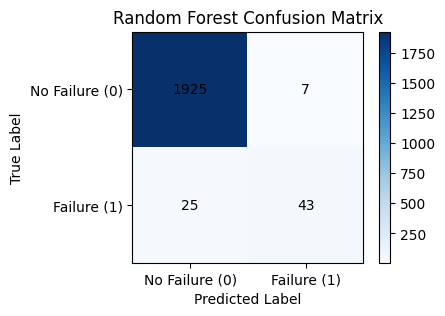

In [31]:
plt.figure(figsize=(4,3))
plt.imshow(cm_rfc, cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["No Failure (0)", "Failure (1)"])
plt.yticks([0, 1], ["No Failure (0)", "Failure (1)"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm_rfc.shape[0]):
    for j in range(cm_rfc.shape[1]):
        plt.text(
            j, i,
            cm_rfc[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.show()

### Insights from Random Forest Confusion Matrix:

* Random Forest significantly improved failure detection, reducing false negatives and maintaining a low number of false positives.

* The model became much better at identifying risky equipment without generating excessive false alarms.

## 8. Models Comparison

The performance of both models is compared below with emphasis on the failure class.

Recall is especially important because missing a real failure can cause costly downtime.

In [32]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.97, 0.98],
    "Precision": [0.60, 0.86],
    "Recall": [0.13, 0.63],
    "F1-score": [0.22, 0.73]
})

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.97,0.60,0.13,0.22
1,Random Forest,0.98,0.86,0.63,0.73


### Insight:

Random Forest outperformed Logistic Regression across all relevant metrics.

- Most importantly, failure recall improved from 13% to 63%, representing nearly a 5x increase in failure detection.

## 7. Model Interpretability: Feature Importance

Feature importance helps identify which operational variables contribute most to failure prediction.

In [33]:
feature_importance = pd.Series(
    rfc.feature_importances_.round(2),
    index=X.columns
).sort_values(ascending=False)

display(feature_importance)

,0
Torque [Nm],0.33
Rotational speed [rpm],0.22
Tool wear [min],0.16
Air temperature [K],0.13
Process temperature [K],0.13
Type,0.02


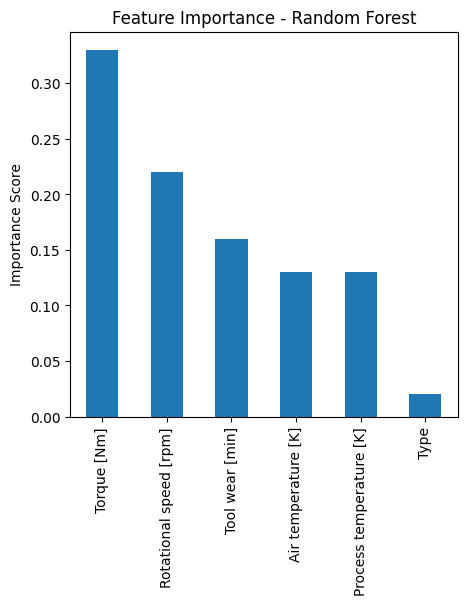

In [34]:
plt.figure(figsize=(5,5))
feature_importance.plot(kind="bar")
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.show()

### Insights:

The three most important predictors were:
- Torque (33%)
- Rotational speed (22%)
- Tool wear (16%)

This indicates that mechanical stress is the main driver of failure.

## 8. Final Conclusions

This project developed a complete machine learning pipeline for predictive maintenance.

### Main findings:
- The dataset was highly imbalanced
- Random Forest outperformed Logistic Regression
- Mechanical stress was the strongest predictor of failure


### Business impact:
Machine learning can help anticipate failures, reduce downtime and optimize maintenance scheduling.
